# 🌀 Énigmes & Merveilles de Clifford Pickover

*Un notebook démo pour matheux, dans l'esprit de Clifford A. Pickover — mathématicien, auteur prolifique
(« The Math Book », « Wonders of Numbers », « Computers, Pattern, Chaos and Beauty », « Chaos in Wonderland »),
explorateur infatigable des curiosités numériques, des fractales biomorphiques et des attracteurs étranges.*

Ce notebook regroupe **9 énigmes / explorations**, mêlant théorie des nombres récréative, systèmes dynamiques
chaotiques et art génératif — de quoi montrer en une seule démo ce que JupyterLab sait faire : calcul, texte,
visualisation et interactivité, le tout au même endroit.

**Sommaire**

1. [Nombres vampires](#1)
2. [Nombres narcissiques généralisés](#2)
3. [Persistance multiplicative](#3)
4. [Attracteur de Clifford](#4)
5. [Biomorphes de Pickover](#5)
6. [Spirale d'Ulam / texture des nombres premiers](#6)
7. [Harmonographe](#7)
8. [Diagramme de bifurcation (carte logistique)](#8)
9. [Bac à sable interactif (ipywidgets)](#9)

> 💡 Astuce démo : lance `Run All Cells` en ouverture, les figures se recalculent sous les yeux du public.


## 1. Nombres vampires <a id="1"></a>

Un **nombre vampire** est un entier $n$ à $2k$ chiffres qui se décompose en un produit de deux "crocs"
(*fangs*) à $k$ chiffres chacun, ces crocs étant eux-mêmes une permutation des chiffres de $n$
(les deux crocs ne peuvent pas se terminer tous les deux par un zéro).

Exemple emblématique : $21 \times 60 = 1260$ — les chiffres de 1260 sont exactement {1,2,6,0}, ceux de 21 et 60 aussi.

Pickover a popularisé ces nombres dans plusieurs de ses ouvrages comme exemple parfait de "beauté cachée"
dans l'arithmétique élémentaire.

In [1]:
from itertools import permutations

def is_vampire(n):
    s = str(n)
    if len(s) % 2 != 0:
        return False
    half = len(s) // 2
    for perm in set(permutations(s)):
        a, b = perm[:half], perm[half:]
        if a[0] == '0' or b[0] == '0':
            continue
        fa, fb = int(''.join(a)), int(''.join(b))
        if fa * fb == n:
            return True
    return False

vampires = [n for n in range(1000, 10000) if is_vampire(n)]
print(f"Nombres vampires à 4 chiffres : {vampires}")
print(f"Il y en a {len(vampires)}.")


Nombres vampires à 4 chiffres : [1260, 1395, 1435, 1530, 1827, 2187, 6880]
Il y en a 7.


## 2. Nombres narcissiques généralisés <a id="2"></a>

Un **nombre narcissique** (ou nombre d'Armstrong) à $k$ chiffres est égal à la somme de ses chiffres
élevés à la puissance $k$. Exemple : $153 = 1^3 + 5^3 + 3^3$.

Pickover aime généraliser : et si l'exposant n'était pas $k$ mais un exposant $p$ fixé arbitrairement,
indépendant du nombre de chiffres ? On obtient une famille beaucoup plus riche (et beaucoup plus rare) de
"nombres parfaitement égocentriques".

In [2]:
def narcissistic_classic(limit=1_000_000):
    result = []
    for n in range(1, limit):
        k = len(str(n))
        if sum(int(d)**k for d in str(n)) == n:
            result.append(n)
    return result

def generalized_narcissistic(power, limit=100_000):
    return [n for n in range(1, limit) if sum(int(d)**power for d in str(n)) == n]

print("Narcissiques classiques < 1 000 000 :", narcissistic_classic())
print()
for p in range(2, 6):
    print(f"Puissance fixe p={p} :", generalized_narcissistic(p))


Narcissiques classiques < 1 000 000 : [1, 2, 3, 4, 5, 6, 7, 8, 9, 153, 370, 371, 407, 1634, 8208, 9474]

Puissance fixe p=2 : [1]
Puissance fixe p=3 : [1, 153, 370, 371, 407]
Puissance fixe p=4 : [1, 8208, 9474]
Puissance fixe p=5 : [1, 4150, 4151, 54748, 92727, 93084]


## 3. Persistance multiplicative <a id="3"></a>

Concept cher à Pickover (et à Neil Sloane) : la **persistance multiplicative** d'un entier est le nombre
d'étapes nécessaires pour atteindre un nombre à un seul chiffre en multipliant répétitivement les chiffres
entre eux. Exemple : $68 \to 48 \to 32 \to 6$ → persistance 3.

Curiosité ouverte : on ne connaît **aucun nombre de persistance ≥ 12**, et on conjecture qu'il n'en existe
peut-être pas — un joli terrain pour une démo "calcul + conjecture".

In [3]:
def persistence(n):
    steps = 0
    while n >= 10:
        p = 1
        for d in str(n):
            p *= int(d)
        n = p
        steps += 1
    return steps

best = max(((persistence(n), n) for n in range(1, 100_000)), key=lambda t: t[0])
print(f"Record de persistance multiplicative sous 100 000 : {best[1]} → {best[0]} étapes")

n = best[1]
chain = [n]
while n >= 10:
    n = eval('*'.join(str(n)))
    chain.append(n)
print(" → ".join(map(str, chain)))


Record de persistance multiplicative sous 100 000 : 68889 → 7 étapes
68889 → 2985984 → 3359232 → 1259712 → 108 → 8


## 4. L'attracteur de Clifford <a id="4"></a>

Et voilà le clin d'œil ultime : l'**attracteur de Clifford** porte littéralement le nom de Clifford Pickover,
qui l'a découvert en explorant des systèmes dynamiques 2D itératifs simples :

$$x_{n+1} = \sin(a\,y_n) + c\cos(a\,x_n)$$
$$y_{n+1} = \sin(b\,x_n) + d\cos(b\,y_n)$$

Pour presque tous les $(a,b,c,d)$, l'orbite reste bornée et dessine des structures fractales magnifiques —
Pickover en a fait toute une esthétique dans ses livres sur l'art génératif.

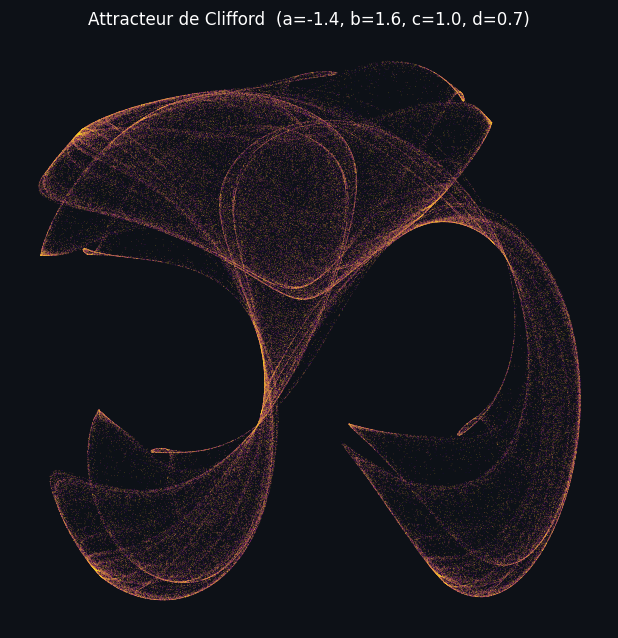

In [4]:
import numpy as np
import matplotlib.pyplot as plt

def clifford(a, b, c, d, n=200_000, x0=0.1, y0=0.0):
    x, y = x0, y0
    xs, ys = np.empty(n), np.empty(n)
    for i in range(n):
        x, y = np.sin(a*y) + c*np.cos(a*x), np.sin(b*x) + d*np.cos(b*y)
        xs[i], ys[i] = x, y
    return xs, ys

a, b, c, d = -1.4, 1.6, 1.0, 0.7
xs, ys = clifford(a, b, c, d)

fig, ax = plt.subplots(figsize=(7,7), facecolor="#0d1117")
ax.set_facecolor("#0d1117")
ax.scatter(xs, ys, s=0.15, c=np.linspace(0,1,len(xs)), cmap="plasma", alpha=0.6, linewidths=0)
ax.set_axis_off()
ax.set_title(f"Attracteur de Clifford (a={a}, b={b}, c={c}, d={d})", color="white")
plt.show()


## 5. Biomorphes de Pickover <a id="5"></a>

Pickover découvre en 1986 que de petites variantes du test d'échappement des fractales de Julia
(en testant $|Re(z)|$ et $|Im(z)|$ séparément plutôt que $|z|$) produisent des motifs étrangement
**organiques** — des formes qui ressemblent à des insectes, algues ou micro-organismes. Il baptise ça
les **biomorphes**, et le terme a depuis été repris en art génératif bio-inspiré.

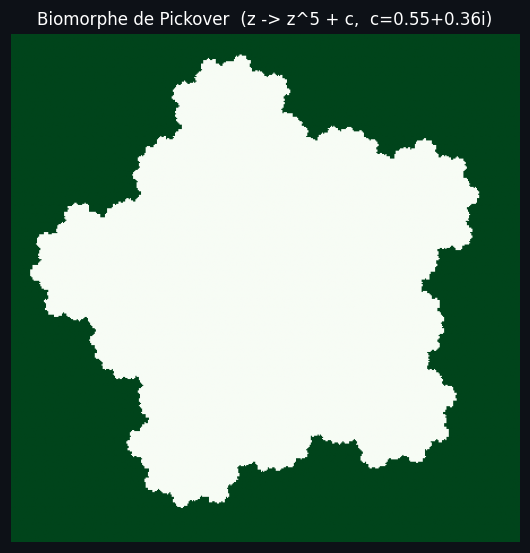

In [5]:
def biomorph(xmin, xmax, ymin, ymax, w=450, h=450, iters=12, bailout=10, c=complex(0.55, 0.36), power=5):
    xs = np.linspace(xmin, xmax, w)
    ys = np.linspace(ymin, ymax, h)
    X, Y = np.meshgrid(xs, ys)
    Z = X + 1j*Y
    escaped = np.zeros(Z.shape, dtype=bool)
    for _ in range(iters):
        Z = Z**power + c
        mask = (np.abs(Z.real) > bailout) | (np.abs(Z.imag) > bailout)
        escaped |= mask
        Z[mask] = bailout
    return np.where(escaped, 0, 1).astype(float)

img = biomorph(-1.2, 1.2, -1.2, 1.2, c=complex(0.55, 0.36))

fig, ax = plt.subplots(figsize=(6,6), facecolor="#0d1117")
ax.set_facecolor("#0d1117")
ax.imshow(img, cmap="Greens_r", extent=[-1.2,1.2,-1.2,1.2])
ax.set_axis_off()
ax.set_title("Biomorphe de Pickover  (z → z⁵ + c,  c = 0.55+0.36i)", color="white")
plt.show()


## 6. Spirale d'Ulam — texture des nombres premiers <a id="6"></a>

Un classique que Pickover a lui-même exploré et prolongé sous forme de « stalactites de nombres premiers » :
placer les entiers en spirale carrée et colorier les nombres premiers révèle des alignements diagonaux
saisissants — traces visuelles de polynômes générateurs de nombres premiers riches (type $n^2+n+41$
d'Euler).

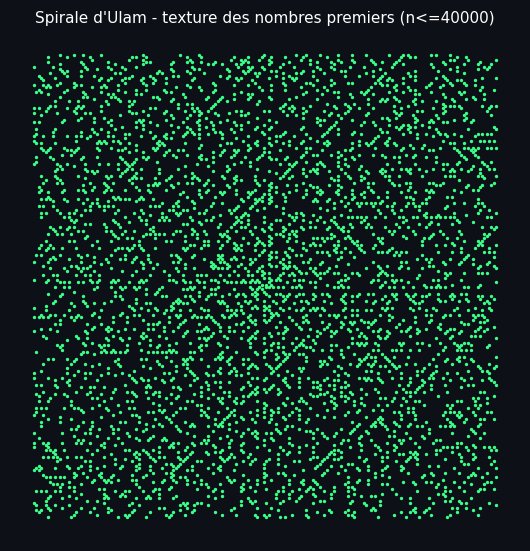

In [6]:
def sieve(n):
    is_p = np.ones(n+1, dtype=bool)
    is_p[:2] = False
    for i in range(2, int(n**0.5)+1):
        if is_p[i]:
            is_p[i*i::i] = False
    return is_p

N = 200*200
is_p = sieve(N)

x, y, dx, dy, steps = 0, 0, 1, 0, 1
coords = [(0,0)]
while len(coords) < N:
    for _ in range(2):
        for _ in range(steps):
            x += dx; y += dy
            coords.append((x,y))
            if len(coords) >= N: break
        if len(coords) >= N: break
        dx, dy = -dy, dx
    steps += 1

xs_ = np.array([p[0] for p in coords[:N]])
ys_ = np.array([p[1] for p in coords[:N]])
nums = np.arange(1, N+1)
prime_mask = is_p[nums]

fig, ax = plt.subplots(figsize=(6,6), facecolor="#0d1117")
ax.set_facecolor("#0d1117")
ax.scatter(xs_[prime_mask], ys_[prime_mask], s=1.4, c="#39ff88")
ax.set_aspect("equal")
ax.set_axis_off()
ax.set_title(f"Spirale d'Ulam — nombres premiers (n ≤ {N})", color="white")
plt.show()


## 7. Harmonographe <a id="7"></a>

Instrument mécanique victorien (deux pendules couplés traçant une courbe avec du sable ou de l'encre) que
Pickover adore citer comme pont entre mathématiques, physique et art — une belle façon de montrer que le
chaos déterministe peut aussi être *joli* plutôt qu'effrayant.

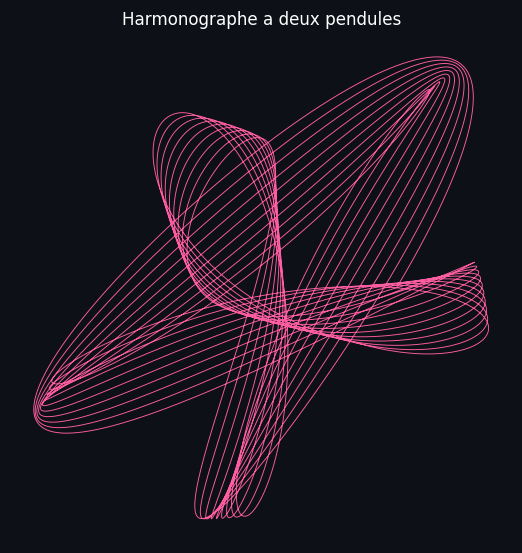

In [7]:
def harmonograph(t, A1,f1,p1,d1, A2,f2,p2,d2, A3,f3,p3,d3, A4,f4,p4,d4):
    x = A1*np.sin(t*f1+p1)*np.exp(-d1*t) + A2*np.sin(t*f2+p2)*np.exp(-d2*t)
    y = A3*np.sin(t*f3+p3)*np.exp(-d3*t) + A4*np.sin(t*f4+p4)*np.exp(-d4*t)
    return x, y

t = np.linspace(0, 60, 20000)
x, y = harmonograph(t, 1,2.99,0.0,0.001, 1,2.0,1.5708,0.0008, 1,3.01,0.0,0.001, 1,2.0,0.0,0.0009)

fig, ax = plt.subplots(figsize=(6,6), facecolor="#0d1117")
ax.set_facecolor("#0d1117")
ax.plot(x, y, color="#ff5da2", lw=0.6)
ax.set_axis_off(); ax.set_aspect("equal")
ax.set_title("Harmonographe à deux pendules", color="white")
plt.show()


## 8. Diagramme de bifurcation — la carte logistique <a id="8"></a>

$$x_{n+1} = r\,x_n(1-x_n)$$

Un des systèmes les plus étudiés par Pickover dans « Chaos in Wonderland » : en faisant varier $r$, on
observe des doublements de période successifs jusqu'au chaos — la fameuse **route de Feigenbaum vers le
chaos**, visible d'un seul coup d'œil.

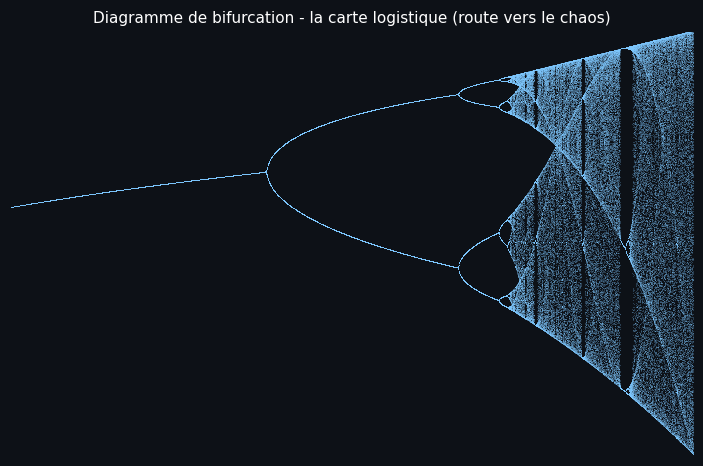

In [8]:
r = np.linspace(2.4, 4.0, 2000)
x = 1e-5*np.ones_like(r)

fig, ax = plt.subplots(figsize=(8,5), facecolor="#0d1117")
ax.set_facecolor("#0d1117")
iterations, last = 1000, 200
for i in range(iterations):
    x = r*x*(1-x)
    if i >= iterations - last:
        ax.plot(r, x, ',', color="#7ec8ff", alpha=0.25, markersize=0.3)
ax.set_xlim(2.4, 4.0); ax.set_ylim(0, 1)
ax.set_axis_off()
ax.set_title("Diagramme de bifurcation de la carte logistique", color="white")
plt.show()


## 9. Bac à sable interactif <a id="9"></a>

Pour la démo live : sliders `ipywidgets` pour explorer la famille d'attracteurs de Clifford (et cousins
« Peter de Jong », lui aussi très pickoverien) en temps réel. Idéal pour montrer à un public de matheux
que JupyterLab, ce n'est pas juste "exécuter du code" — c'est un vrai laboratoire visuel interactif.

> ⚠️ Nécessite `ipywidgets` installé et activé dans l'environnement JupyterLab (`pip install ipywidgets`).

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, FloatSlider

def plot_clifford(a=-1.4, b=1.6, c=1.0, d=0.7, n=60000):
    x, y = 0.1, 0.0
    xs, ys = np.empty(n), np.empty(n)
    for i in range(n):
        x, y = np.sin(a*y) + c*np.cos(a*x), np.sin(b*x) + d*np.cos(b*y)
        xs[i], ys[i] = x, y
    fig, ax = plt.subplots(figsize=(6,6), facecolor="#0d1117")
    ax.set_facecolor("#0d1117")
    ax.scatter(xs, ys, s=0.2, c=np.linspace(0,1,n), cmap="plasma", alpha=0.6, linewidths=0)
    ax.set_axis_off()
    ax.set_title(f"a={a:.2f}  b={b:.2f}  c={c:.2f}  d={d:.2f}", color="white")
    plt.show()

interact(plot_clifford,
         a=FloatSlider(-1.4, min=-3, max=3, step=0.05),
         b=FloatSlider(1.6, min=-3, max=3, step=0.05),
         c=FloatSlider(1.0, min=-3, max=3, step=0.05),
         d=FloatSlider(0.7, min=-3, max=3, step=0.05))


## Pour aller plus loin

Quelques pistes de lecture pour prolonger la démo :

- **Clifford A. Pickover**, *The Math Book: From Pythagoras to the 57th Dimension* (2009)
- **Clifford A. Pickover**, *Computers, Pattern, Chaos and Beauty* (1990) — la source des biomorphes et de l'attracteur éponyme
- **Clifford A. Pickover**, *Wonders of Numbers* (2001)
- **Clifford A. Pickover**, *Chaos in Wonderland* (1994)
- [pickover.com](http://pickover.com) — le site personnel, toujours foisonnant

---
*Notebook généré pour une démo JupyterLab — libre à toi de piocher, couper, ou dupliquer les cellules
selon le public (plus théorie des nombres pour des arithméticiens, plus attracteurs/fractales pour un
public plus visuel).*
